In [1]:
source("preparar_dataframes.r")
source("src/sstvars_wrapper.r")


[1] "Se creó df_trimestral_crudo"
[1] "Se creó df_Arg"
[1] "Se creó df_ERPT_Arg1"
[1] "Se creó df_ERPT_Arg"


Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.data.frame zoo 


Attaching package: ‘sstvars’


The following object is masked from ‘package:tsDyn’:

    GIRF




In [2]:
df_ERPT_Arg_1950_75 <- df_ERPT_Arg[1:103, ]
rownames(df_ERPT_Arg_1950_75) <- NULL
print(df_ERPT_Arg_1950_75)
tail(df_ERPT_Arg_1950_75)

     año trimestre           ipc             E           Ebc         pbird
1   1950      2ºTr  0.0710476068  0.000000e+00  0.000000e+00 -0.0164445777
2   1950      3ºTr  0.0485426448  1.822569e-01  1.822569e-01  0.0376749288
3   1950      4ºTr  0.0686389229  2.596392e-01  2.596392e-01 -0.0129753136
4   1951      1ºTr  0.0228032118  1.405321e-03  1.405321e-03  0.0271279177
5   1951      2ºTr  0.1578569708  4.855918e-03  4.855918e-03  0.0120849848
6   1951      3ºTr  0.1057701537  6.299697e-03  6.299697e-03 -0.0062139270
7   1951      4ºTr  0.0767790005  1.347034e-02  1.347034e-02 -0.0043864484
8   1952      1ºTr  0.1087066196 -1.618821e-02 -1.618821e-02  0.0024196794
9   1952      2ºTr  0.0994670088 -1.171674e-02 -1.171674e-02 -0.0324056598
10  1952      3ºTr -0.0146396976 -2.180054e-03 -2.180054e-03 -0.0513198674
11  1952      4ºTr  0.0335589046 -1.192593e-05 -1.192593e-05  0.0088992684
12  1953      1ºTr  0.0266918756 -4.770412e-06 -4.770412e-06  0.0265101685
13  1953      2ºTr -0.038

,año,trimestre,ipc,E,Ebc,pbird,impp_usa,Psoja_USA,Pmaíz_USA,Ptrigo_USA,TOTfmi
,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
98,1974,3ºTr,0.08159092,0.0000000,0.0000000,0.0008571713,0.0655126054,0.30337495,0.25415173,0.12945807,NA
99,1974,4ºTr,0.13376657,0.0000000,0.0000000,0.0112117424,0.0340040317,0.07614865,0.04689952,0.13144589,NA
100,1975,1ºTr,0.17652291,0.8501509,0.1578655,-0.0043070843,0.0085075416,-0.26727915,-0.15481491,-0.20469952,NA
101,1975,2ºTr,0.25282326,0.5039645,0.5421054,-0.0024821955,0.0102602586,-0.11159908,-0.06982378,-0.14988991,NA
102,1975,3ºTr,0.61078946,0.7741162,1.0090191,-0.0342827927,-0.0352475739,0.05644131,0.04985835,0.11690081,NA
103,1975,4ºTr,0.37973156,0.5559811,0.3338426,0.0094609638,0.0007550019,-0.18354181,-0.14118644,-0.02865012,NA


Se cargó exitosamente modelos preguardados  threshold_tvar_1_2_500_bf80dadf6c8c5445776ee9bf7eace0b6.rds  de la carpeta models

 >>> TESTS
PARA CORRER LOS TESTS CORRER LA SIGUIENTE FUNCION:
run_tests_sstvar(res, c(' ipc '), TRUE , NULL , 1 , 500 )

 >>> DIAGNOSTIC PLOTS


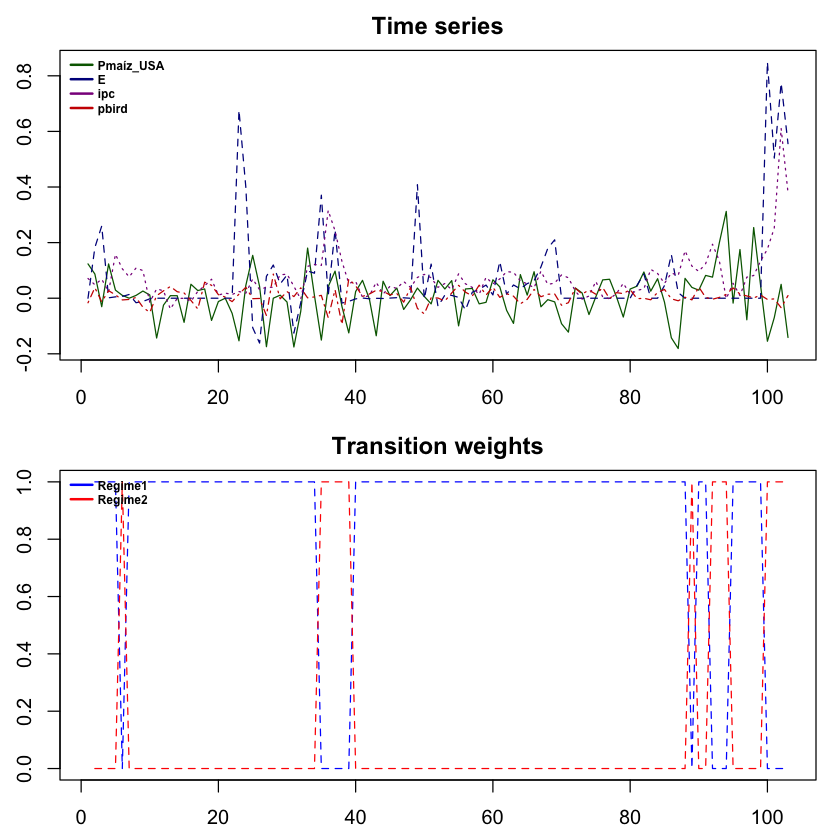

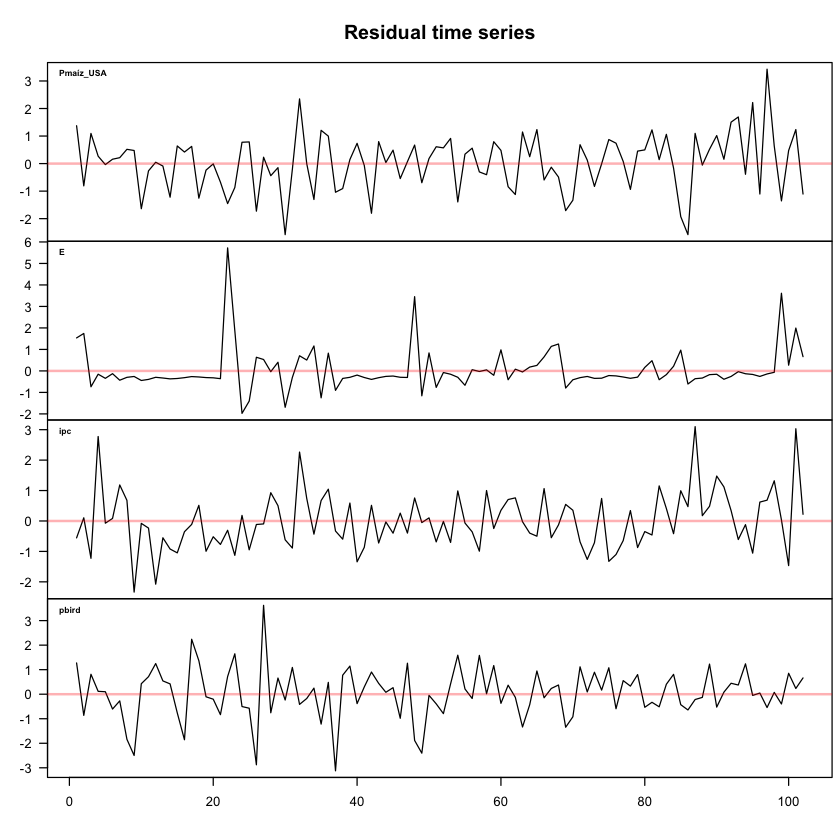

+++++++++ RÉGIMEN  1 +++++++++
 >>> GIRF ( 1  shock units)


Using 6 cores to estimate 250 GIRFs for 1 structural shocks, each based on 500 Monte Carlo repetitions.

Estimating GIRFs for structural shock 2...

Finished!



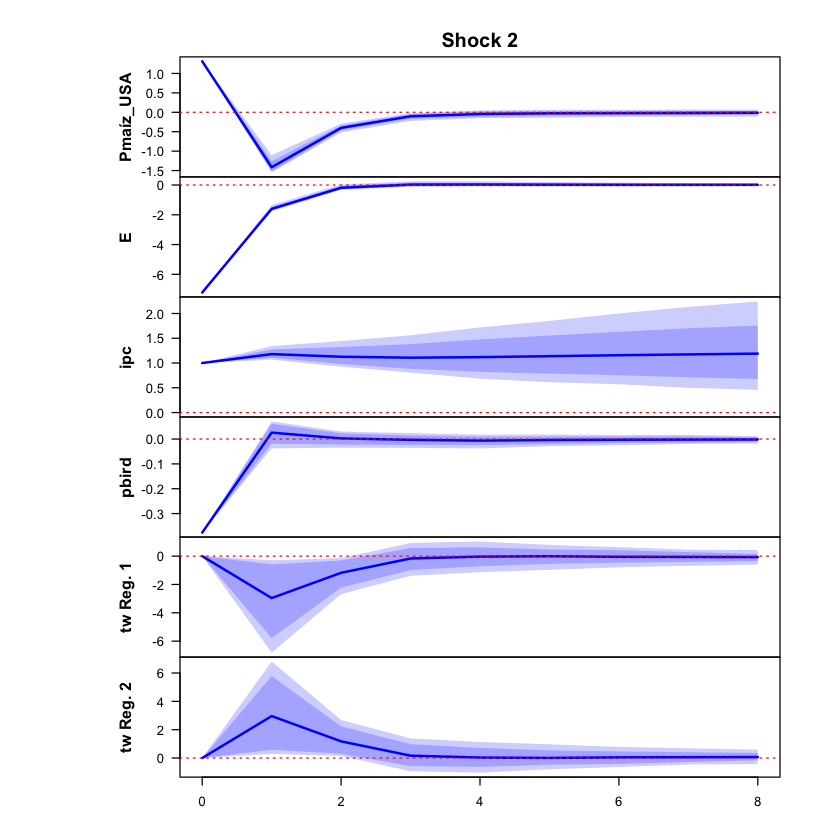

 >>> Linear IRF ( 1  shock units)


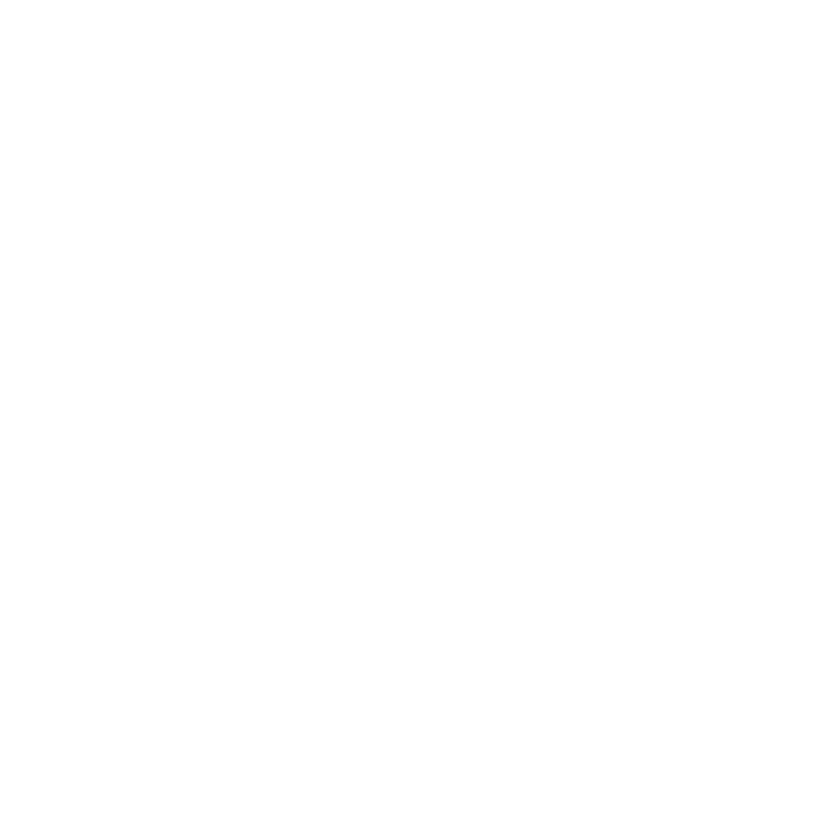

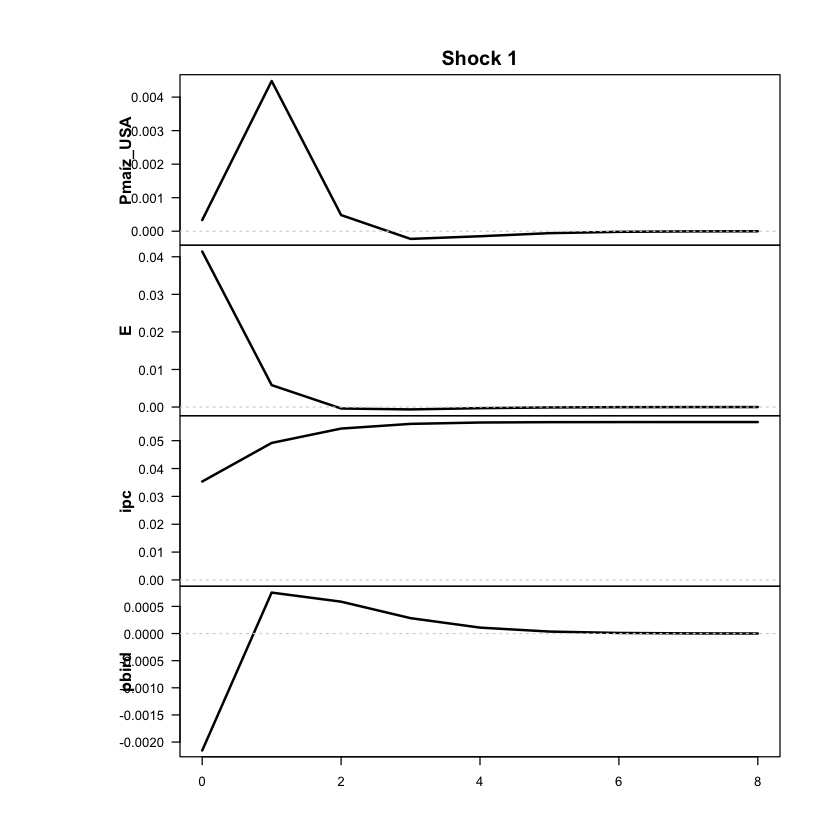

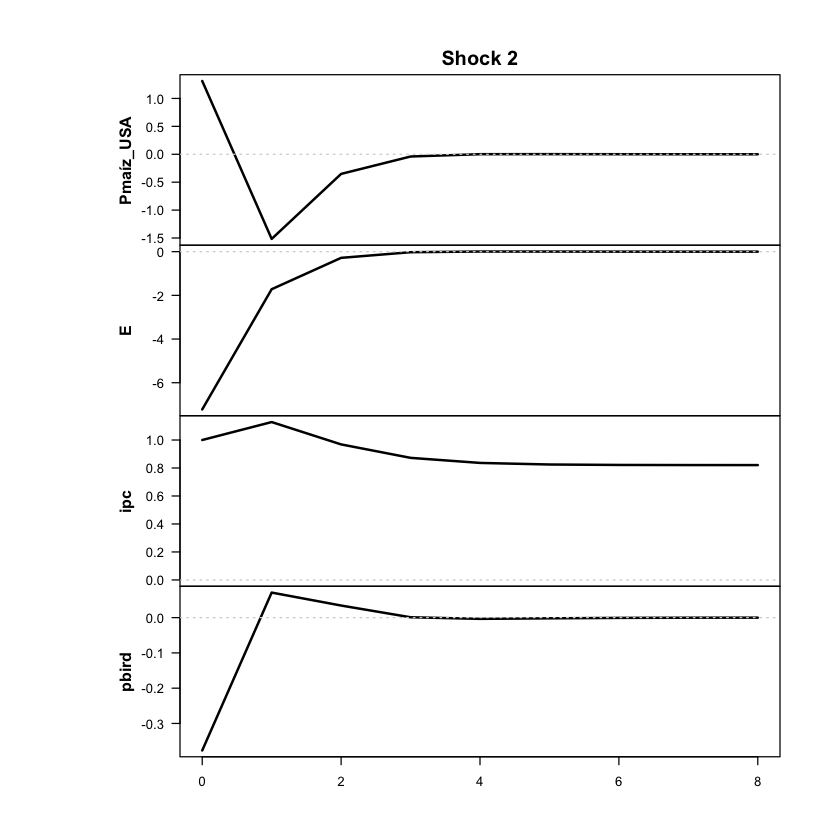

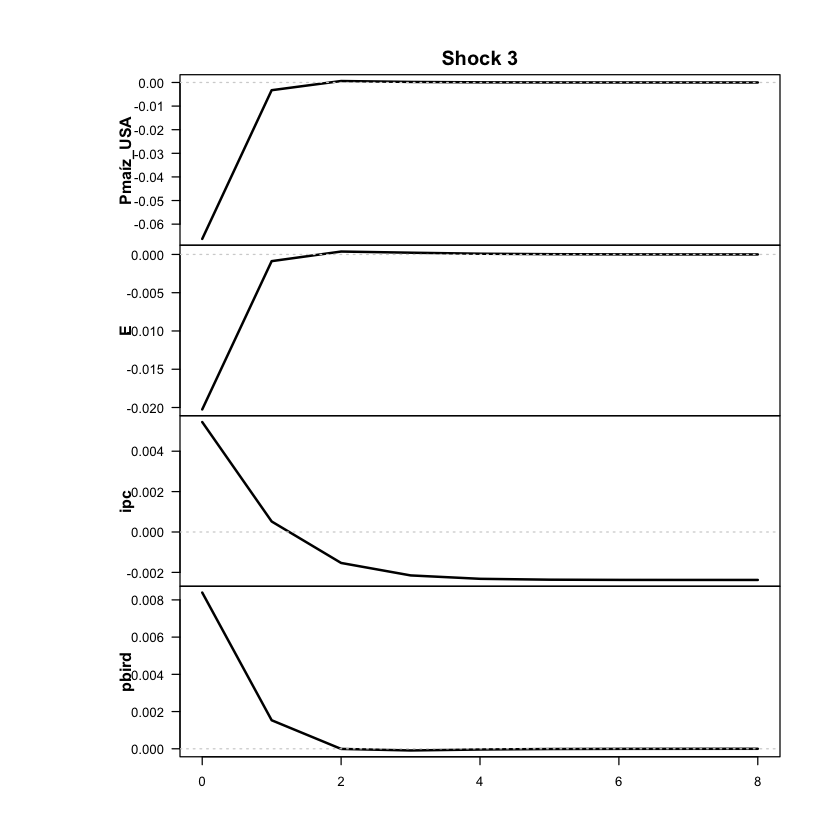

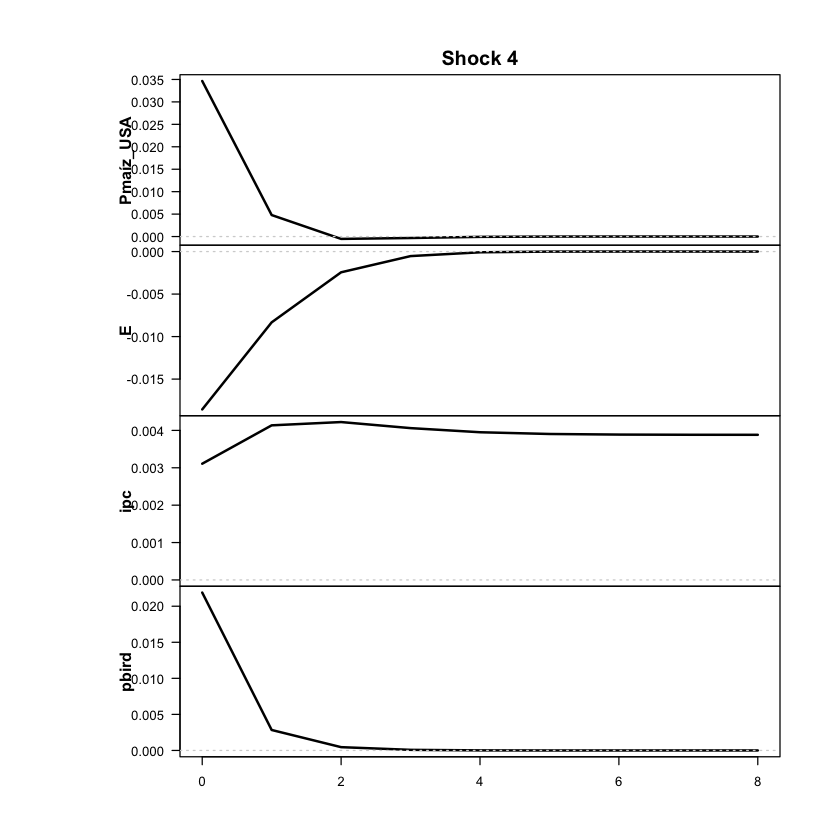

+++++++++ RÉGIMEN  2 +++++++++
 >>> GIRF ( 1  shock units)


Using 6 cores to estimate 250 GIRFs for 1 structural shocks, each based on 500 Monte Carlo repetitions.

Estimating GIRFs for structural shock 2...

Finished!



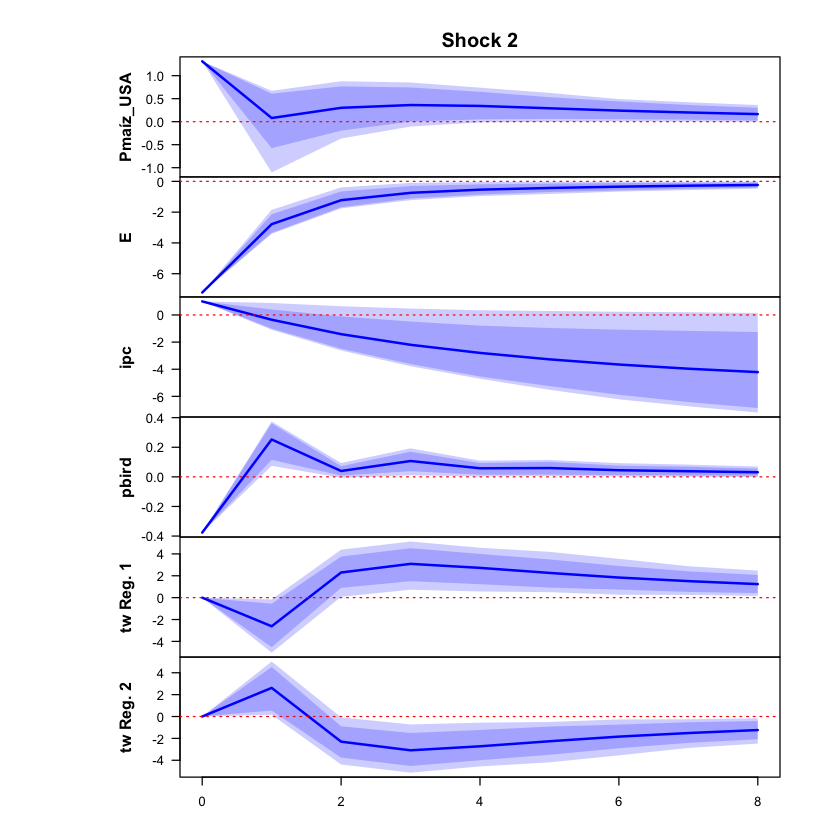

 >>> Linear IRF ( 1  shock units)


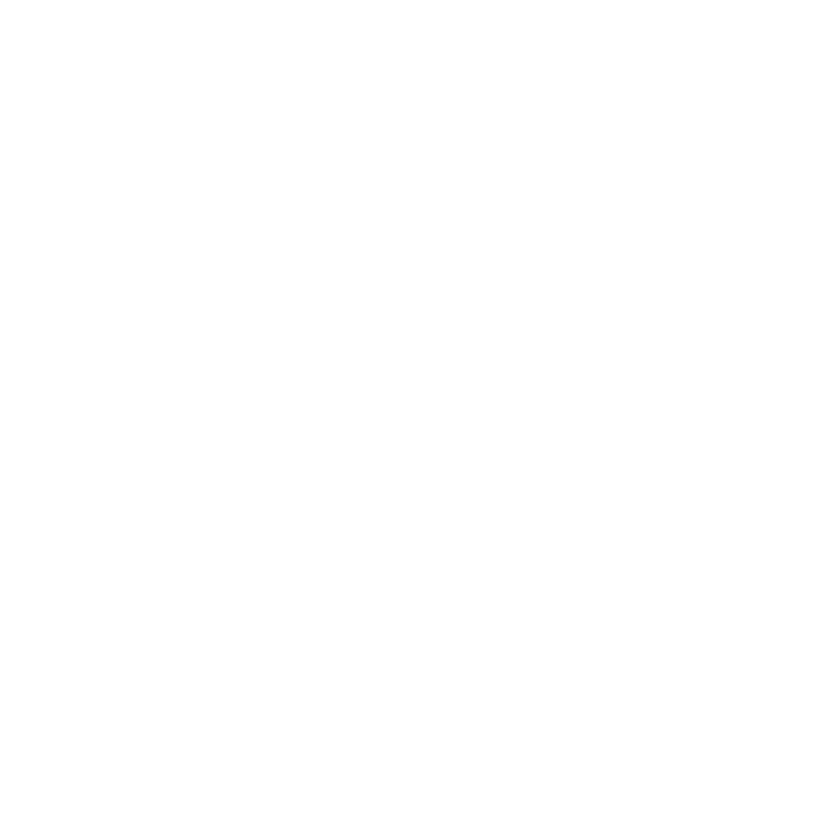

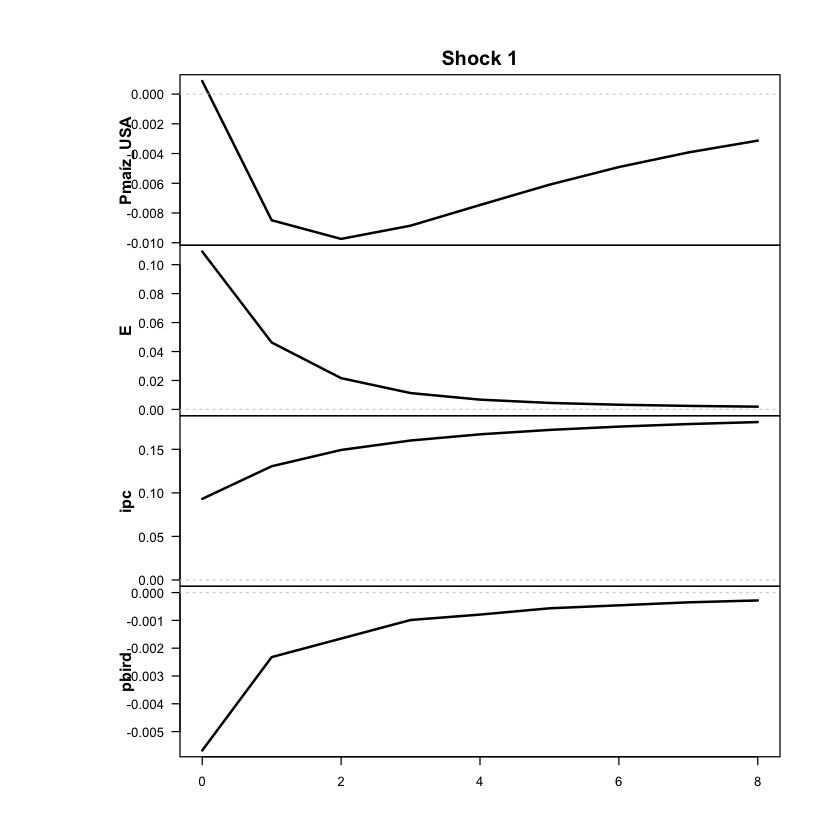

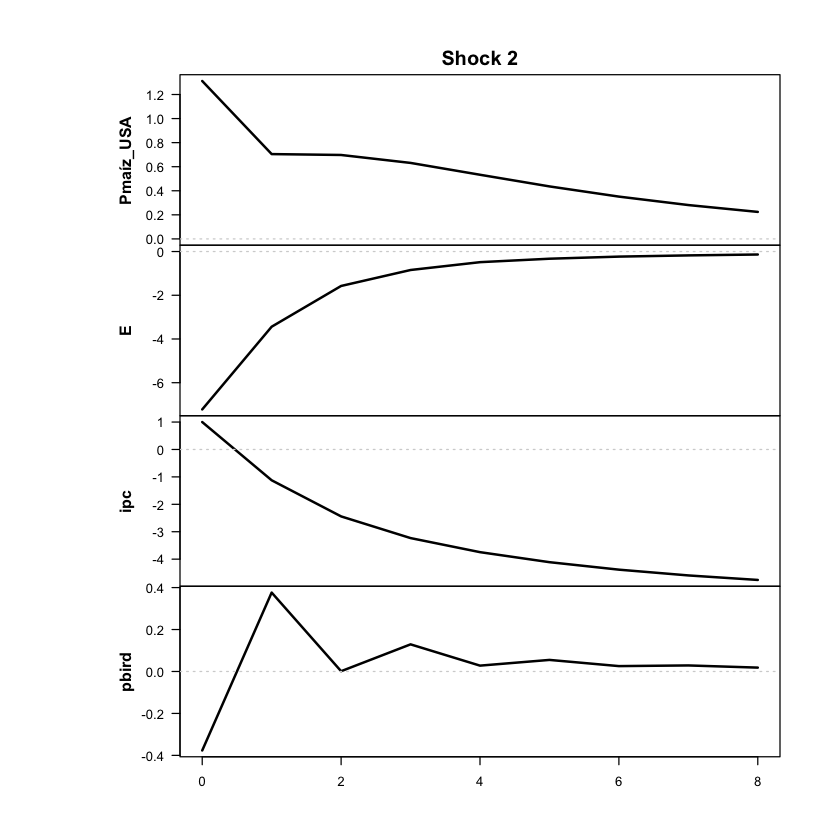

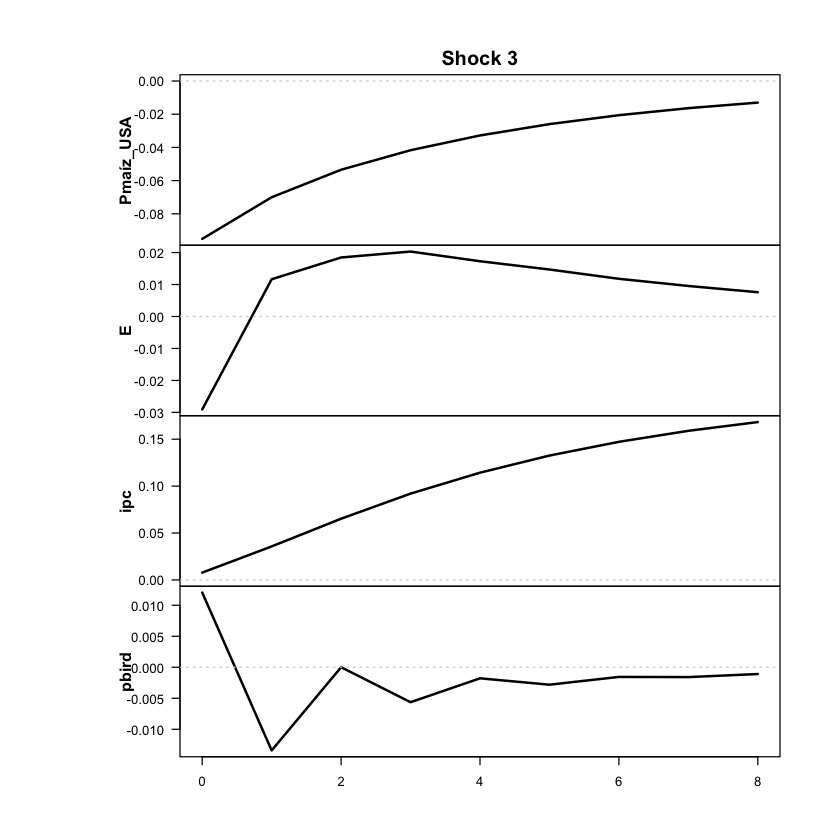

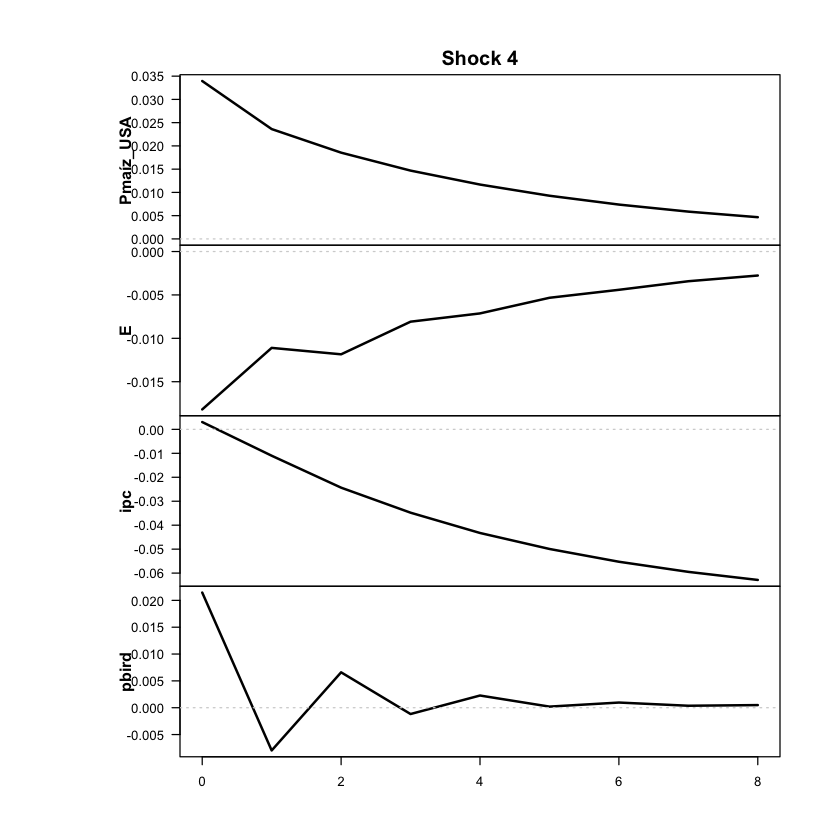

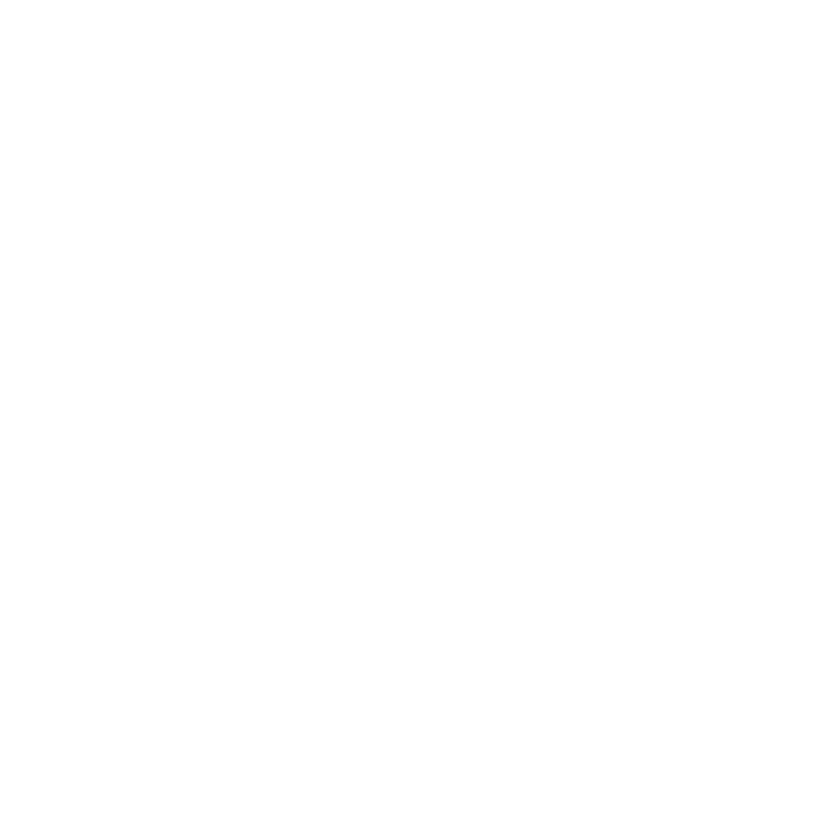

In [3]:
res <- run_threshold_tvar(
  data = df_ERPT_Arg_1950_75,
  endog = c("Pmaíz_USA","E","ipc","pbird"),
  periodicity = 'trimestral', # 'trimestral' o 'anual' o mensual
  feature_lag = 1,
  n_regimes = 2,
  cumulative = TRUE,
  thr_var = 'ipc', # 'ipc'
  thr_lag = 1,
  shock_var = 'E', # 'E'
  response_vars = c('ipc'), # c("Pmaíz_USA","ipc","pbird")
  run_tests = TRUE, # ejecuta e imprime tests: portmonteau, descomposición histórica y GEFVD
  irf_horizons = NULL, # Max períodos hacia los que mirar adelante en IRF (NULL = 2 años, default = 2 años)
  irf_shocks = 1, # Shocks unitarios irf (default 1)
  diagnostic_plots = TRUE, # Imprimir plots de diagnostico? TRUE o FALSE (default FALSE)
  nrounds = 500, # Cantidad de iteraciones - para ver resultados poco confiables rápido poner bajito, si no dejar en 500 o incluso 1000 (default 500)
  load_presaved = TRUE
)
#Correr los siguientes en celdas aparte
#print_girf(res) #Si querés ver los resultados de GIRF, descomentame
#print_irf(res) #Si querés ver los resultados de IRF lineal, descomentame
# OJO: A ESTA HAY QUE PASARLE LOS MISMOS PARÁMETROS QUE A RUN_VLSTAR!!
#run_tests_sstvar(res, response_vars = c('ipc'), cumulative = TRUE, irf_horizons = NULL, irf_shocks = 1, nrounds = 1)

In [15]:

print_irf <- function(res) {
  for (i in 1:length(res$regimes)) {
    cat("+++++++++ RÉGIMEN ", i, "+++++++++\n")
    print(res$regimes[[i]]$lirf)
  }
}

print_girf <- function(res) {
  for (i in 1:length(res$regimes)) {
    cat("+++++++++ RÉGIMEN ", i, "+++++++++\n")
    print(res$regimes[[i]]$girf)
  }
}

In [16]:
print_girf(res) #Si querés ver los resultados de GIRF, descomentame

+++++++++ RÉGIMEN  1 +++++++++
The responses of the variables ipc were cumulated. 

The GIRF of shock 2: 
The response of Pmaíz_USA: 
   2.5%   10%  mean   90% 97.5%
0  1.31  1.31  1.31  1.31  1.31
1 -1.55 -1.52 -1.41 -1.26 -1.10
2 -0.52 -0.47 -0.40 -0.34 -0.29
3 -0.22 -0.17 -0.10 -0.04 -0.02
4 -0.15 -0.12 -0.04  0.02  0.05
5 -0.14 -0.09 -0.03  0.03  0.07
6 -0.12 -0.08 -0.02  0.04  0.06
7 -0.11 -0.07 -0.02  0.04  0.07
8 -0.11 -0.06 -0.01  0.03  0.07

The response of E: 
   2.5%   10%  mean   90% 97.5%
0 -7.22 -7.22 -7.22 -7.22 -7.22
1 -1.77 -1.72 -1.60 -1.47 -1.34
2 -0.33 -0.29 -0.18 -0.06  0.04
3 -0.12 -0.08  0.03  0.16  0.25
4 -0.10 -0.06  0.03  0.15  0.24
5 -0.12 -0.07  0.02  0.11  0.20
6 -0.11 -0.06  0.02  0.10  0.16
7 -0.09 -0.06  0.02  0.09  0.13
8 -0.08 -0.04  0.02  0.08  0.12

The response of ipc: 
  2.5%  10% mean  90% 97.5%
0 1.00 1.00 1.00 1.00  1.00
1 1.07 1.11 1.18 1.28  1.34
2 0.93 0.98 1.13 1.32  1.45
3 0.81 0.88 1.11 1.38  1.56
4 0.68 0.82 1.12 1.48  1.72
5 0.61 0.78 1.

In [17]:
print_irf(res)

+++++++++ RÉGIMEN  1 +++++++++
The responses of the variables ipc were cumulated. 

The IRF of Shock 1: 
  Pmaíz_USA    E  ipc pbird
0      0.00 0.04 0.04  0.00
1      0.00 0.01 0.05  0.00
2      0.00 0.00 0.05  0.00
3      0.00 0.00 0.06  0.00
4      0.00 0.00 0.06  0.00
5      0.00 0.00 0.06  0.00
6      0.00 0.00 0.06  0.00
7      0.00 0.00 0.06  0.00
8      0.00 0.00 0.06  0.00

------------------------
The IRF of Shock 2: 
  Pmaíz_USA     E   ipc pbird
0      1.31 -7.22  1.00 -0.38
1     -1.52 -1.72  1.13  0.07
2     -0.35 -0.28  0.97  0.03
3     -0.04 -0.02  0.87  0.00
4      0.00  0.01  0.84  0.00
5      0.00  0.00  0.83  0.00
6      0.00  0.00  0.82  0.00
7      0.00  0.00  0.82  0.00
8      0.00  0.00  0.82  0.00

------------------------
The IRF of Shock 3: 
  Pmaíz_USA     E   ipc pbird
0     -0.07 -0.02  0.01  0.01
1      0.00  0.00  0.00  0.00
2      0.00  0.00  0.00  0.00
3      0.00  0.00  0.00  0.00
4      0.00  0.00  0.00  0.00
5      0.00  0.00  0.00  0.00
6      0.00